# Investigating the $C_0$ parameter in the pdf of $DM_{\rm cosmic}$

The pdf for the cosmic dispersion measure is given by:

$$
p(\Delta) = A \Delta^{-\beta} \exp \left[ -\frac{(\Delta^{-\alpha} - C_0)^2}{2 \alpha^2 \sigma^2} \right], \quad \Delta>0,
$$

where $\Delta = DM_c/\langle DM_c \rangle$, $\alpha, \beta$ are connected to the density profiles of halos. In the following, we choose $(\alpha, \beta) = (3, 3)$, which provide good match with numerical simulations.

The $A$ parameter is found by normalising the pdf:

$$
\int_0^\infty p(\Delta) d\Delta = 1.
$$

The $C_0$ parameter is found from the consistency relation:

$$
\langle \Delta \rangle = 1 \rightarrow \int_0^\infty \Delta p(\Delta) d\Delta = 1.
$$

The $\sigma$ parameter should be fixed by observations:

$$
\sigma = F/\sqrt{z}
$$


The background of the formalism above, can be found in the paper [here](https://www.nature.com/articles/s41586-020-2300-2).

------------------------------------------------------------

**Main problem**:

The calculation of $C_0$ is not straightforward. It depends on $\sigma$ and we need to fit its value, so that an integral gives a certain value. If we combine the condition of $A$ and $\langle \Delta \rangle$, we need to fix $C_0$ such that:

$$
\int_0^\infty (\Delta-1) p(\Delta) d\Delta = 0.
$$

With fixed parameters $(\alpha, \beta)$, this depends only on $\sigma$. Someone can also take the ratio of the integrals, to cancel $A$ (see Jiaming's analysis in the `FRB_DM_z` notebook).

-------------------------------

## Import modules and packages

In [1]:
import timeit
import numpy as np
import pandas as pd

import scipy.interpolate as sip

# Plotting
import matplotlib.pyplot as plt
from matplotlib import rcParams

## Attempt 1: Can we find an approximate solution?

The whole idea of the approximation, lies into considering two limiting cases, where $\Delta \ll 1$ and $\Delta \gg 1$, which will create the following integrals:

$$
\int_0^1 \frac{\Delta-1}{\Delta^\beta} f(\Delta, z) d\Delta + f(C_0, z) \int_1^\infty \frac{\Delta-1}{\Delta^\beta} d\Delta = 0, 
$$

where $f(\Delta, C_0, z) = \exp \left[ -\frac{(\Delta^{-\alpha} - C_0)^2}{2 \alpha^2 \sigma(z)^2} \right]$. In the specific limits, $f$ depends on fewer parameters. From the above equation, we can separate $f(C_0, z)$ and solve for $C_0$. This leads to the approximate solution (for the above values of $\alpha$ and $\beta$):

$$
C_0 = \sqrt{-18 F^2/z \cdot \ln{(-2I_1)}}, 
$$

with $I_1 = \int_0^1 \frac{\Delta-1}{\Delta^\beta} f(\Delta, z)$, which doesn't depend on $C_0$ and can be quickly calculated for a specific redshift.

Let's try the approximation, and fixing $F=0.1$ (the value where we have some precise data for $C_0$, by solving the full integral).

In [2]:
alpha, beta, F0 = 3, 3, 0.1

In [3]:
def f(D, z):
    """
    Helpful function, when calculating the integral I_1.
    """
    exponent = D**(-2*alpha)/(2*alpha**2*F0**2/z)
    return np.exp(-exponent)


def I1_integral(z, Deltas):
    I1 = np.trapz((Deltas-1)*f(Deltas, z)/Deltas**beta, Deltas)
    return I1


def C0_approximation(z, Deltas):
    """
    Function that calculated the approximate C0
    """
    
    factor = -18*F0**2/z
    ln_int = np.log(-2*I1_integral(z, Deltas))
    
    return np.sqrt(factor*ln_int)

In [4]:
## This goes only from 0->1, since this is needed for the first integral above
Delta_array = np.linspace(0.01, 1, 500)


## Let's calculate some approximate C0 values for a range of redshifts
z_values = np.linspace(0.5, 20, 200)
C0_approx = np.zeros_like(z_values)

for idx, z in enumerate(z_values):
    C0_approx[idx] = C0_approximation(z, Delta_array)

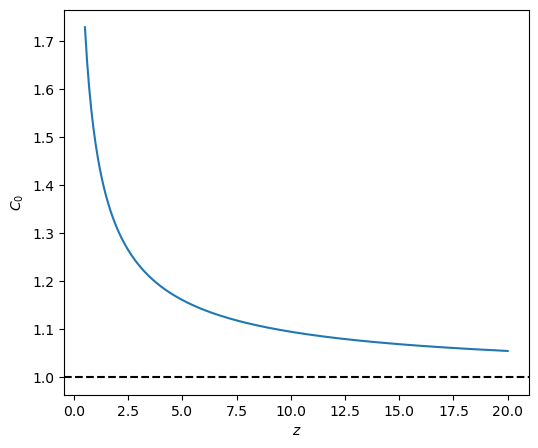

In [5]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values, C0_approx)
ax.axhline(y=1, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$C_{0}$")

plt.show()

The line $y=1$ is also plotted, because in the case of $z \gg 1 \Rightarrow \sigma \rightarrow 0$, the exponential yields a $\delta$-function, that requires $C_0 \rightarrow 1$ (but convergence there is slow, since $\sigma \sim 1/\sqrt{z})$.

**How well do the $C_0$ approximations work when comparing to precise $C_0$ values?**

We have generated values for $(\alpha, \beta, F) = (3, 3, 0.1)$ by solving the full integral and fitting the required $C_0$ (see `FRB_DM_z` notebook). We compare these $C_0$ values, with the ones computed here using our approximation.

In [6]:
## Read data pairs of (z, C_0)
df = pd.read_csv('C_0_z_v2.csv', sep=',')


## Create arrays of z, C0 data
z_values_precise = np.array(df['z'])
Co_values_precise = np.array(df['C_0'])

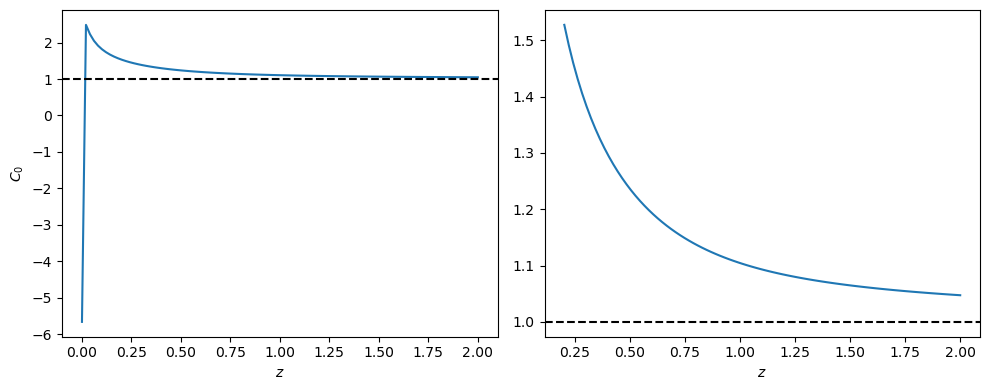

In [7]:
fig= plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_values_precise, Co_values_precise)
ax1.axhline(y=1, ls='--', c='black')
ax1.set_xlabel(r"$z$")
ax1.set_ylabel(r"$C_{0}$")

ax2.plot(z_values_precise[z_values_precise>0.2], Co_values_precise[z_values_precise>0.2])
ax2.axhline(y=1, ls='--', c='black')
ax2.set_xlabel(r"$z$")

plt.tight_layout()
plt.show()

We can ignore the very low-z value that leads to negative $C_0$ and compare the rest:

In [8]:
C0_approx_compare = np.zeros_like(z_values_precise[1:])

for idx, z in enumerate(z_values_precise[1:]):
    C0_approx_compare[idx] = C0_approximation(z, Delta_array)

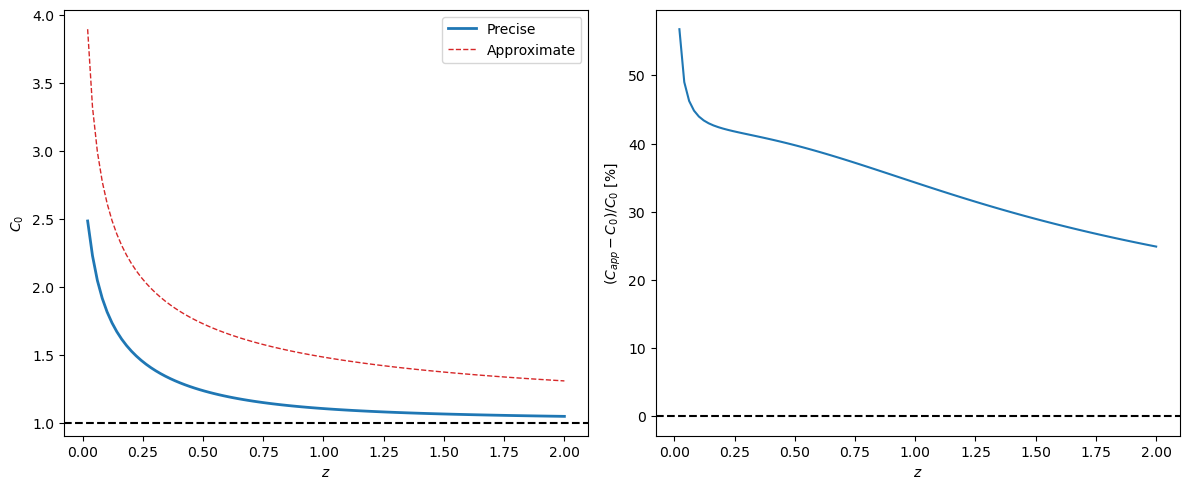

In [9]:
fig= plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)


ax1.plot(z_values_precise[1:], Co_values_precise[1:], c='tab:blue', lw=2, label='Precise')
ax1.plot(z_values_precise[1:], C0_approx_compare, c='tab:red', lw=1, ls='--', label='Approximate')
ax1.axhline(y=1, ls='--', c='black')

ax1.legend()
ax1.set_xlabel(r"$z$")
ax1.set_ylabel(r"$C_{0}$")


ax2.plot(z_values_precise[1:], (C0_approx_compare-Co_values_precise[1:])/Co_values_precise[1:]*100)
ax2.axhline(y=0, ls='--', c='black')
ax2.set_xlabel(r"$z$")
ax2.set_ylabel(r"$(C_{app}-C_{0})/C_0$ [%]")

plt.tight_layout()
plt.show()

The difference can be significant ($>50 \%$), and always above $>20 \%$, for the redshift range of interest.

-------------------------------------------

We can see if things improve, when we also add a term when $\Delta \sim 1$:

$$
\frac{\Delta-1}{\Delta^\beta} \exp \left[ -(\Delta^{-\alpha}-C_0)^2/2\alpha^2\sigma^2 \right].
$$

In [11]:
def pdf_delta_big(D, sigma, C0):
    """
    Approximation of the integrand when Δ>>1
    """
    factor = D**(1-beta)
    exponent = -C0**2/(2*alpha**2*sigma**2)
    
    return factor*np.exp(exponent)


def pdf_delta_small(D, sigma, C0):
    """
    Approximation of the integrand when Δ<<1
    """    
    factor = -D**(-beta)
    exponent = -D**(-2*alpha)/(2*alpha**2*sigma**2)
    
    return factor*np.exp(exponent)


def pdf_delta_one(D, sigma, C0):
    """
    Approximation of the integrand when Δ~1
    """    
    factor = D-1
    exponent = -(1-C0)**2/(2*alpha**2*sigma**2)
    
    return factor*np.exp(exponent)


def pdf_delta(D, sigma, C0):
    """
    Full integrand, without any approximations
    """    
    factor = (D-1)/D**beta
    exponent = -(D**(-alpha)-C0)**2/(2*alpha**2*sigma**2)
    
    return factor*np.exp(exponent)

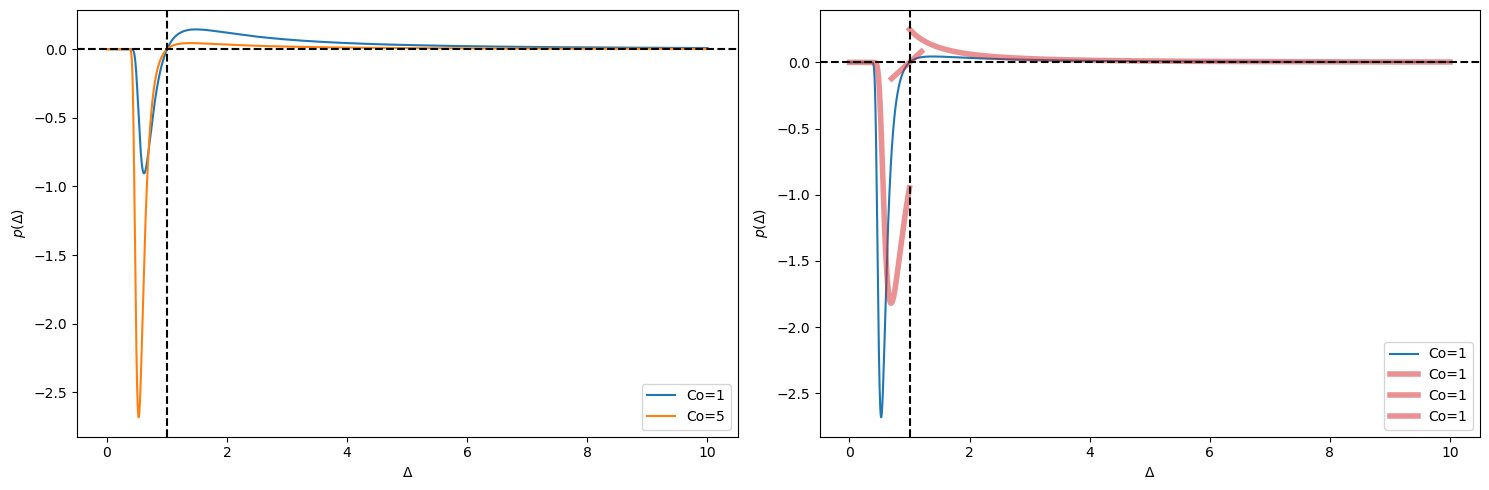

In [16]:
Delta_full = np.linspace(0.001, 10, 5000)
C0 = 5

fig= plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot(Delta_full, pdf_delta(Delta_full, 1, 1), label='Co=1')
ax1.plot(Delta_full, pdf_delta(Delta_full, 1, 5), label='Co=5')
ax1.axhline(y=0, ls='--', c='black')
ax1.axvline(x=1, ls='--', c='black')
ax1.set_xlabel(r"$\Delta$")
ax1.set_ylabel(r"$p(\Delta)$")
ax1.legend()

ax2.plot(Delta_full, pdf_delta(Delta_full, 1, C0), label='Co=1')
ax2.plot(Delta_full[Delta_full>1], pdf_delta_big(Delta_full[Delta_full>1], 1, C0), label='Co=1', c='tab:red', lw=4, alpha=0.5)
ax2.plot(Delta_full[Delta_full<1], pdf_delta_small(Delta_full[Delta_full<1], 1, C0), label='Co=1', c='tab:red', lw=4, alpha=0.5)
ax2.plot(Delta_full[(Delta_full<1.2)*(Delta_full>0.7)], pdf_delta_one(Delta_full[(Delta_full<1.2)*(Delta_full>0.7)], 1, C0), label='Co=1', c='tab:red', lw=4, alpha=0.5)
ax2.axhline(y=0, ls='--', c='black')
ax2.axvline(x=1, ls='--', c='black')
ax2.set_xlabel(r"$\Delta$")
ax2.set_ylabel(r"$p(\Delta)$")
ax2.legend()

plt.tight_layout()
plt.show()

**(Left)**: The full function $p(\Delta)$ for fixed $\sigma$ and $C_0$.

**(Right)**: The comparison of the approximations (red) with the full function at the respective limits of $\Delta$. It is clear from this plot, that the approximation is not behaving great, except for the very extreme cases!

We need to find another way of estimating $C_0$!

## Attempt 2: A numerical-grid solution?

We create a 1D grid array of $C_0$ values, and choose the one that satisfies the "normalisation" condition:

$$
\int_0^\infty (\Delta-1) p(\Delta) d\Delta = 0.
$$

In [21]:
Delta_full = np.linspace(0.001, 100, 5000)
C0_array = np.logspace(-0.2, 0.4, 20)

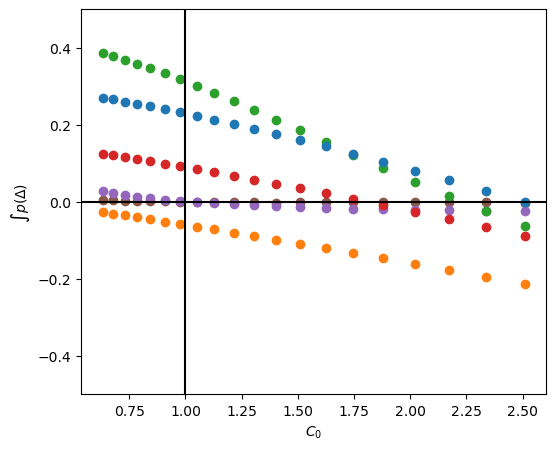

In [22]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)


## Different colours correspond to different values of sigma
for C0 in C0_array:
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 0.01 , C0), Delta_full), c='tab:brown')    
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 0.05 , C0), Delta_full), c='tab:purple')
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 0.5 , C0), Delta_full), c='tab:green')
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 1.0 , C0), Delta_full), c='tab:blue')
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 1.5 , C0), Delta_full), c='tab:red')
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 2.0 , C0), Delta_full), c='tab:orange')    


ax.axhline(y=0, ls='-', c='black')
ax.axvline(x=1, ls='-', c='black')

ax.set_xlabel(r"$C_0$")
ax.set_ylabel(r"$\int p(\Delta)$")

ax.set_ylim(-0.5, 0.5)

plt.show()    

We automate the above procedure with the following function:

For an array of $C_0$ values and error $\sigma$, it returns the $C_0$ value that makes the integral come closer to zero.

In [23]:
def find_C0(Delta_array, C0_array, sigma):
    integral = np.ones_like(C0_array)

    for idx, C0 in enumerate(C0_array):
        integral[idx] = np.trapz(pdf_delta(Delta_array, sigma, C0), Delta_array)
        
    C0_norm = C0_array[np.argwhere(np.min(np.abs(integral))==np.abs(integral))[0][0]]
    
    # C0_norm = C0_array[np.argwhere(np.diff(np.sign(integral))<0)[0][0]]
    
    return C0_norm

Cross-check the function for a series of $\sigma$ values!

In [28]:
## We need high resolution for this method to work
## this is also the main "time bottleneck" of the method
Delta_full = np.linspace(0.001, 100, 5000)
C0_array = np.logspace(-0.2, 0.5, 200)

## Sigma values to test
sigma_values = np.array([0.5, 0.8, 1.0, 1.2, 1.5])
C0_values = np.zeros_like(sigma_values)

for idx, sig in enumerate(sigma_values):
    C0_values[idx] = find_C0(Delta_full, C0_array, sig)

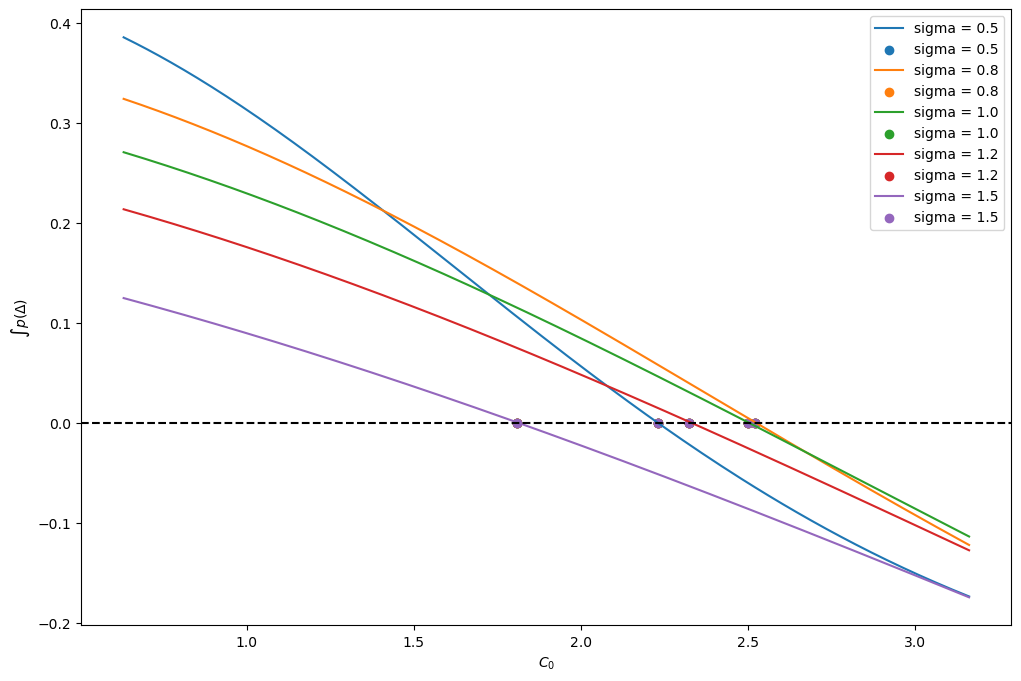

In [31]:
fig= plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)

for sig in sigma_values:
    integral_val = np.ones_like(C0_array)
    for idx, C0 in enumerate(C0_array):
        integral_val[idx] = np.trapz(pdf_delta(Delta_full, sig , C0), Delta_full)
        
    ax.plot(C0_array, integral_val, label=f'sigma = {sig}')
    
    ax.scatter(C0_values, np.zeros_like(sigma_values), label=f'sigma = {sig}')    

ax.axhline(y=0, ls='--', c='black')

ax.set_xlabel(r"$C_0$")
ax.set_ylabel(r"$\int p(\Delta)$")

ax.legend(fontsize=10)


plt.show()    

The method works fine - the dots correspond to the points, where the lines (the integral) crosses zero!

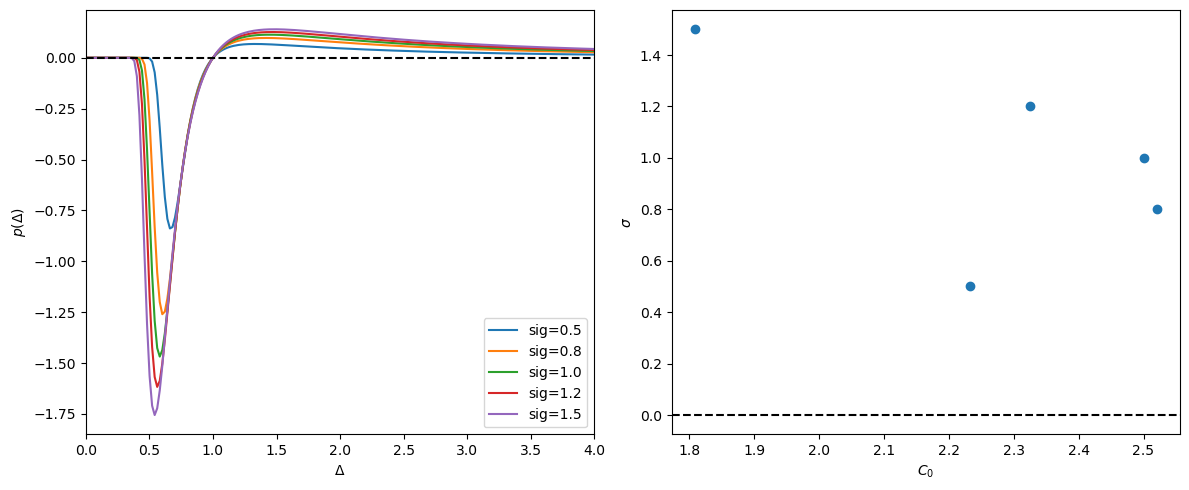

In [34]:
fig= plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)


for idx, sig in enumerate(sigma_values):
    ax1.plot(Delta_full, pdf_delta(Delta_full, sig, C0_values[idx]), label=f'sig={sig}')

ax1.axhline(y=0, ls='--', c='black')
ax1.set_xlabel(r"$\Delta$")
ax1.set_ylabel(r"$p(\Delta)$")
ax1.legend()
ax1.set_xlim(0, 4)

ax2.scatter(C0_values, sigma_values)    
ax2.axhline(y=0, ls='--', c='black')
ax2.set_xlabel(r"$C_0$")
ax2.set_ylabel(r"$\sigma$")

plt.tight_layout()
plt.show() 

The error $\sigma$, depends on $F, z$, through $\sigma = F/\sqrt{z}$. So for a given $F, z$, we can find $\sigma$ and use our function, to calculate $C_0$.

**Note**: This would be the more realistic case, since $F, z$ would be the ones usually given.

In [35]:
def find_C0_from_Fz(Delta_array, C0_array, F, z):
    sigma = F/np.sqrt(z)
    C0 = find_C0(Delta_array, C0_array, sigma)
    
    return C0

In [36]:
Delta_full = np.linspace(0.001, 100, 5000)
C0_array = np.logspace(-0.2, 0.5, 200)
Fs = np.linspace(0.01, 0.5,10)

results = {}

for F in Fs:
    C_0 = find_C0_from_Fz(Delta_full, C0_array, F=F, z=0.2)
    print(f"For F = {F}: C_0 = {C_0}")

For F = 0.01: C_0 = 1.001157747609116
For F = 0.06444444444444444: C_0 = 1.2458833642950078
For F = 0.11888888888888888: C_0 = 1.6676716762659416
For F = 0.17333333333333334: C_0 = 2.0091625541281224
For F = 0.22777777777777777: C_0 = 2.2504082253782736
For F = 0.2822222222222222: C_0 = 2.4010544563721443
For F = 0.33666666666666667: C_0 = 2.500287500476916
For F = 0.3911111111111111: C_0 = 2.5411197149744993
For F = 0.44555555555555554: C_0 = 2.500287500476916
For F = 0.5: C_0 = 2.4205808771359787


In [39]:
C0_quick = np.zeros_like(z_values_precise)

for idx, z in enumerate(z_values_precise):
    C0_quick[idx] = find_C0_from_Fz(Delta_full, C0_array, 0.1, z)

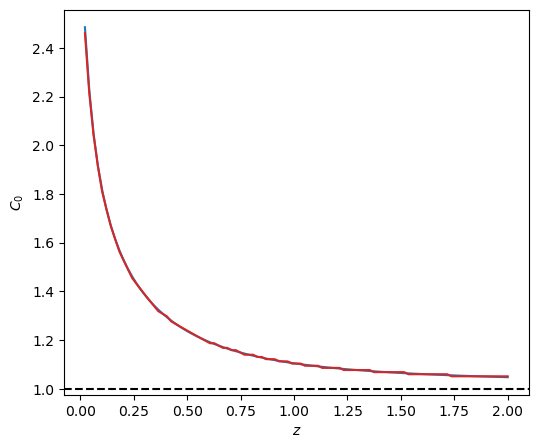

In [40]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values_precise[1:], Co_values_precise[1:])
ax.plot(z_values_precise[1:], C0_quick[1:], c='tab:red')
ax.axhline(y=1, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$C_{0}$")

plt.show()

Above we compare the numerical-grid method, with the more optimised version (see Jiaming's analysis in the `FRB_DM_z` notebook). The results are comparable, but the grid creates some "step-like" behaviour in the `numerical-grid` approach.

Below we estimate the timing (which will depend on resolution):

In [41]:
print("\n Timing for Marios:")
%timeit find_C0_from_Fz(Delta_full, C0_array, 0.1, 1)


 Timing for Marios:
97.3 ms ± 5.83 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


**Note**: This is really bad, considering that $C_0$ do not play any important physical role in the analysis, and is just needed for normalisation, when computing the other parameters. Taking so much time, creates an obstacle to the efficient inference of the real physical variables.

-------------------------------------------

## Attempt 3: Creating interpolating function for $C_0$?

Our method is precise, but slow! We can speed things up, by using the precise method for a few points of $\sigma$ and interpolate for the full range. We have seens that the behaviour of $C_0$ as a function of $\sigma$ (see above), is quite a smooth function, so the interpolation should work nicely! And be fast!

In [44]:
Delta_full = np.linspace(0.001, 100, 5000)
C0_array = np.logspace(-0.2, 0.5, 500)


## The values we want to interpolate!
sigma_array = np.linspace(0.1, 1.5, 20)

C0_values = np.zeros_like(sigma_array)

for idx, sig in enumerate(sigma_array):
    C0_values[idx] = find_C0(Delta_full, C0_array, sig)

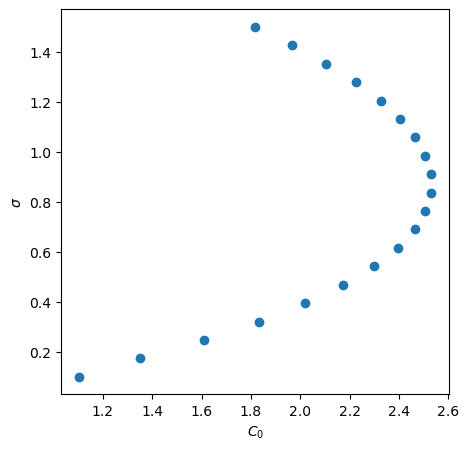

In [45]:
fig= plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
   
ax.scatter(C0_values, sigma_array)    
ax.set_xlabel(r"$C_0$")
ax.set_ylabel(r"$\sigma$")

plt.show() 

In [46]:
## Create the interpolation
C0_interp = sip.interp1d(sigma_array, C0_values)

In [47]:
## Test the interpolation for a range of sigma values
sigma_detailed = np.linspace(0.1, 1.5, 40)
C0_interpolation = C0_interp(sigma_detailed)

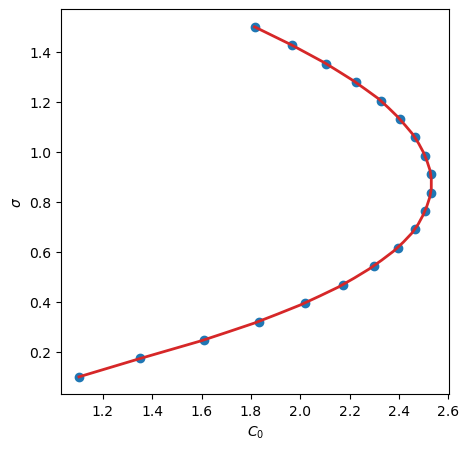

In [48]:
fig= plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
   
ax.scatter(C0_values, sigma_array)    
ax.plot(C0_interpolation, sigma_detailed, ls='-', lw=2, c='tab:red')
ax.set_xlabel(r"$C_0$")
ax.set_ylabel(r"$\sigma$")

plt.show() 

Below we time the interpolation method, and we see that it is about 3 orders of magnitude faster!

In [49]:
%timeit C0_interp(sigma_detailed)

20 µs ± 916 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [50]:
def find_C0_from_interpolated_Fz(F, z):
    sigma = F/np.sqrt(z)
    C0 = C0_interp(sigma)

    return C0

Finally, let's compare the interpolated function, with the precise values:

In [64]:
## The maximum and minimum values of sigma are:
np.max(0.1/z_values_precise[1:]), np.min(0.1/z_values_precise[1:])

(4.718779790276475, 0.05)

We do not expect to have sigmas much bigger than 1.5, so we need to take this into account, by trimming the `z_values_precise`!

In [70]:
0.1/z_values_precise[:5]

array([100.        ,   4.71877979,   2.41640225,   1.62401575,
         1.22297715])

So we need to keep `z_values_precise[i>3]`, i.e. $\sigma \leq 1.7$!

In [81]:
## These are different that the initial interpolation, so we create a new one

Delta_full = np.linspace(0.001, 100, 5000)
C0_array = np.logspace(-1, 0.5, 500)


## The values we want to interpolate! Change to **COVER** the ones provided!
sigma_array = np.linspace(0.02, 1.7, 40)

C0_values = np.zeros_like(sigma_array)

for idx, sig in enumerate(sigma_array):
    C0_values[idx] = find_C0(Delta_full, C0_array, sig)
    

## Create the interpolation
C0_interp = sip.interp1d(sigma_array, C0_values)

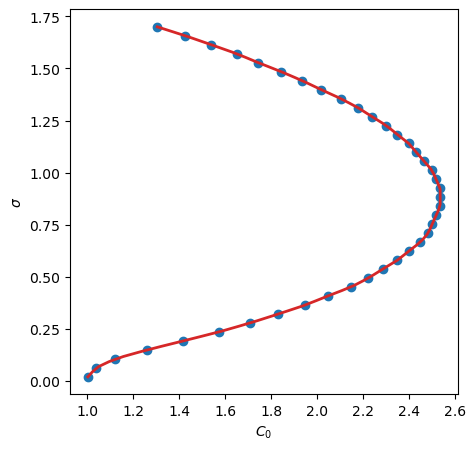

In [82]:
## Test the new interpolation for a range of sigma values
sigma_detailed = np.linspace(0.02, 1.7, 70)
C0_interpolation = C0_interp(sigma_detailed)

fig= plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
   
ax.scatter(C0_values, sigma_array)    
ax.plot(C0_interpolation, sigma_detailed, ls='-', lw=2, c='tab:red')
ax.set_xlabel(r"$C_0$")
ax.set_ylabel(r"$\sigma$")

plt.show() 

In [83]:
## Calculate the interpolation values
C0_interpolation = np.zeros_like(z_values_precise[3:])

for idx, z in enumerate(z_values_precise[3:]):
    C0_interpolation[idx] = find_C0_from_interpolated_Fz(0.1, z)

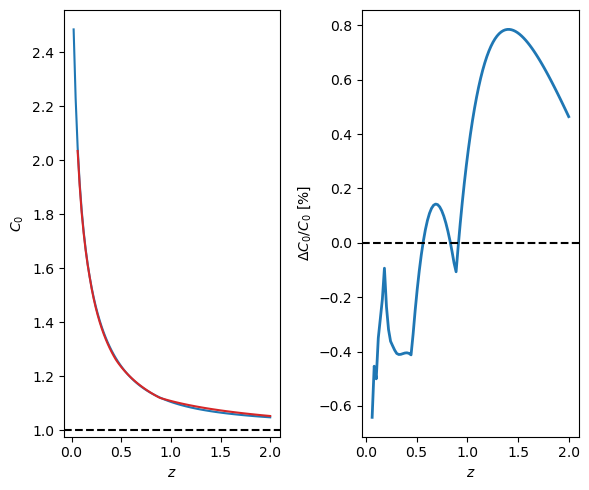

In [89]:
fig= plt.figure(figsize=(6,5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot(z_values_precise[1:], Co_values_precise[1:])
ax1.plot(z_values_precise[3:], C0_interpolation, c='tab:red')
ax1.axhline(y=1, ls='--', c='black')
ax1.set_xlabel(r"$z$")
ax1.set_ylabel(r"$C_{0}$")


ax2.plot(z_values_precise[3:], (C0_interpolation-Co_values_precise[3:])/Co_values_precise[3:]*100,\
         c='tab:blue', lw=2)
ax2.axhline(y=0, ls='--', c='black')
ax2.set_xlabel(r"$z$")
ax2.set_ylabel(r"$\Delta C_{0}/C_0$ [%]")

plt.tight_layout()
plt.show()

**Note**: We need to be careful how to construct the interpolation, but then it is precise enough (less than 1% error, for all redshifts of interest)